In [78]:
import csv
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt  
from ipywidgets import interact, FloatSlider
from datetime import datetime

import os

import numpy as np
from numpy.linalg import solve

import pandas as pd
from scipy.interpolate import BSpline

import seaborn as sns

from scipy.linalg import lstsq

from scipy.stats import pearsonr

import matplotlib.dates as mdates

import importlib
import function
importlib.reload(function)
from function import *

# Données

## Données régionales

In [79]:

FILEPATHS_regional = {
    "vv": "data/Data/StudyCase_S1_Trinité/ts_s1a_21NZF_vv_ASC_120_867km2.csv",
    "vh": "data/Data/StudyCase_S1_Trinité/ts_s1a_21NZF_vh_ASC_120_867km2.csv",
}

def extract_signal_regional(polarization, masking="masked"):
    """
    Extrait la série temporelle depuis les fichiers CSV S1A.

    Args:
        polarization (str): "vv" ou "vh"
        masking (str):       "masked" ou "unmasked"

    Returns:
        pd.DataFrame: colonnes ["date", "mean_value"], triées par date
    """
    polarization = polarization.lower()
    masking = masking.lower()

    if polarization not in FILEPATHS_regional:
        raise ValueError(f"polarization doit être 'vv' ou 'vh', reçu : '{polarization}'")
    if masking not in ("masked", "unmasked"):
        raise ValueError(f"masking doit être 'masked' ou 'unmasked', reçu : '{masking}'")

    col = f"moy_{masking}"

    df = pd.read_csv(FILEPATHS_regional[polarization])
    df["date"] = pd.to_datetime(df["date"])

    return (
        df[["date", col]]
        .rename(columns={col: "mean_value"})
        .sort_values("date")
        .reset_index(drop=True)
    )

## Données locales

## Modalités disponibles

| Paramètre       | Valeurs possibles                        |
|:----------------|:-----------------------------------------|
| `subzone`       | `1` `2` `3` `4` `5` `6` `7` `8` `9` `10` |
| `type_veg`      | `"fol"` `"defol"` `"nodata"`             |
| `polarization`  | `"vh"` `"vv"`                            |
| `orbite`        | `39` `120`                               |
| `direction`     | `"ASC"` `"DES"`                          |
| `satellite`     | `"s1a"` `"s1b"` `"s1c"`                  |

In [80]:
FILEPATH_local = "data/Data/StudyCase_S1_Trinité/ts_10subzones_defoliated.csv"

def extract_signal_local(subzone, type_veg, polarization, orbite, direction, satellite=None):
    def to_list(val):
        return [val] if not isinstance(val, list) else val

    df = pd.read_csv(FILEPATH_local)
    df["subzone_id"] = df["shapefile_name"].str.extract(r"subzone(\d+)").astype(int)

    mask = (
        df["subzone_id"].isin(to_list(subzone)) &
        df["type"].isin(to_list(type_veg)) &
        df["polarization"].isin(to_list(polarization)) &
        df["orbite"].isin(to_list(orbite)) &
        df["direction"].isin(to_list(direction))
    )
    if satellite is not None:
        mask &= df["satellite"].isin(to_list(satellite))

    df_filtered = df[mask].copy()
    df_filtered["date"] = pd.to_datetime(df_filtered["date"], format="%Y%m%d")

    return df_filtered[["date", "mean_value"]].sort_values("date").reset_index(drop=True)

# Splines Regression

## Fonctions

In [81]:
# ════════════════════════════════════════════════════════════
#  PARAMÈTRES GLOBAUX
# ════════════════════════════════════════════════════════════
ALPHA = 3.0   # Mallows Cp (3=Kooperberg, 2=AIC, log(n)=BIC)


# ════════════════════════════════════════════════════════════
#  RÉGRESSION RÉGIONALE (B-spline pénalisée + sélection Cp)
# ════════════════════════════════════════════════════════════

def run_regional_spline(ts: pd.DataFrame, use_mallows: bool = True) -> dict:
    """
    Ajustement régional par B-spline pénalisée.

    Paramètres
    ----------
    ts           : DataFrame avec colonnes 'date' (datetime) et 'mean_value'
    use_mallows  : True  → sélection du nombre de nœuds via critère Mallows Cp
                   False → n_knots = nombre de points du signal

    Retourne
    --------
    dict avec : dates, values, t_numeric, n_knots, lam, Y_hat, history
    """
    dates    = ts["date"].values
    values   = ts["mean_value"].values
    dates_dt = pd.to_datetime(dates)

    t_numeric = np.array([(d - dates_dt[0]).days for d in dates_dt], dtype=float)

    print(f"  n = {len(values)}")

    # — Sélection du nombre de nœuds —
    if use_mallows:
        print(f"  Sélection du nombre de nœuds (alpha={ALPHA}) ...\n")
        n_knots, history = stepwise_knot_selection_bspline(t_numeric, values, alpha=ALPHA)
    else:
        n_knots = len(ts)
        history = None
        print(f"  n_knots fixé au nombre de points : {n_knots}\n")

    std_reg = np.std(values)

    B        = build_bspline_basis(t_numeric, n_knots)
    lam_opt  = optimize_lambda_gcv(B, values)
    _, Y_hat = penalized_spline_fit(B, values, lam_opt)

    # — Graphe 1 : critère Cp (uniquement si Mallows) —
    sns.set_style("whitegrid")
    plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

    if use_mallows:
        plt.figure(figsize=(14, 5))
        plt.plot(history["n_knots"], history["Cp"], "o-", color="steelblue", linewidth=2)
        plt.axvline(n_knots, color="tomato", linestyle="--",
                    label=f"Optimal : {n_knots} nœuds")
        plt.xlabel("Nombre de nœuds")
        plt.ylabel("Mallows $C_p$")
        plt.title("Critère de sélection Mallows $C_p$")
        plt.gca().invert_xaxis()
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # — Graphe 2 : ajustement final —
    mode_label = f"Mallows Cp | n_knots={n_knots}" if use_mallows else f"n_knots={n_knots} (nb points)"

    plt.figure(figsize=(14, 5))
    plt.plot(dates_dt, values, '-o', color='tab:blue', alpha=0.45,
             linewidth=1.5, markersize=5, label="Signal original")
    plt.plot(dates_dt, Y_hat, color='tomato', linewidth=2.5,
             label=f"Spline optimale | {mode_label} | λ={lam_opt:.2e}")
    plt.xlabel("Date")
    plt.ylabel("Rétrodiffusion (dB)")
    plt.title("Ajustement final — Régression régionale")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "dates"    : dates_dt,
        "values"   : values,
        "t_numeric": t_numeric,
        "n_knots"  : n_knots,
        "lam"      : lam_opt,
        "Y_hat"    : Y_hat,
        "reg_std"  : std_reg,
        "history"  : history,   # None si use_mallows=False
    }

# ════════════════════════════════════════════════════════════
#  SPLINE LOCALE
# ════════════════════════════════════════════════════════════

def run_local_spline(ts: pd.DataFrame,lam_regional,std_regional,condition_cgv) -> dict:
    """
    Ajustement local par B-spline pénalisée avec n_knots = len(ts).

    Paramètre
    ---------
    ts : DataFrame avec colonnes 'date' (datetime) et 'mean_value'

    Retourne
    --------
    dict avec : dates, values, t_numeric, n_knots, lam, Y_hat
    """
    dates    = ts["date"].values
    values   = ts["mean_value"].values
    dates_dt = pd.to_datetime(dates)

    t_numeric = np.array([(d - dates_dt[0]).days for d in dates_dt], dtype=float)
    n_knots   = len(ts)

    
    std_loc = np.std(values)

    B        = build_bspline_basis(t_numeric, n_knots)
    if condition_cgv==True: 
        lam_opt  = optimize_lambda_gcv(B, values)
    else: 
        lam_opt = (std_loc / std_regional)**(2) * lam_regional
        #lam_opt = ((std_regional - std_loc)/ std_loc) * lam_regional

    _, Y_hat = penalized_spline_fit(B, values, lam_opt)

    # — Graphe : ajustement local —
    sns.set_style("whitegrid")
    plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

    plt.figure(figsize=(14, 5))
    plt.plot(dates_dt, values, '-o', color='tab:blue', alpha=0.45,
             linewidth=1.5, markersize=5, label="Signal original")
    plt.plot(dates_dt, Y_hat, color='tomato', linewidth=2.5,
             label=f"Spline locale | n_knots={n_knots} | λ={lam_opt:.2e}")
    plt.xlabel("Date")
    plt.ylabel("Rétrodiffusion (dB)")
    plt.title("Ajustement final — Spline locale")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "dates"    : dates_dt,
        "values"   : values,
        "t_numeric": t_numeric,
        "n_knots"  : n_knots,
        "lam"      : lam_opt,
        "std_err"  : std_loc,
        "Y_hat"    : Y_hat,
    }

# Regression

## Splines Regionales

  n = 262
  n_knots fixé au nombre de points : 262



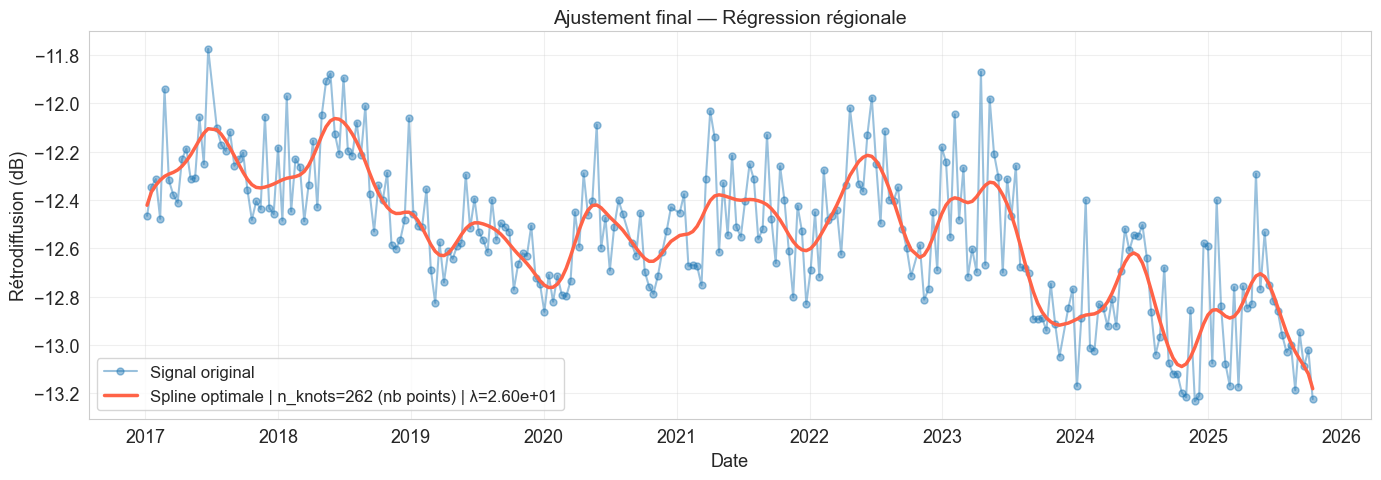

  n = 262
  n_knots fixé au nombre de points : 262



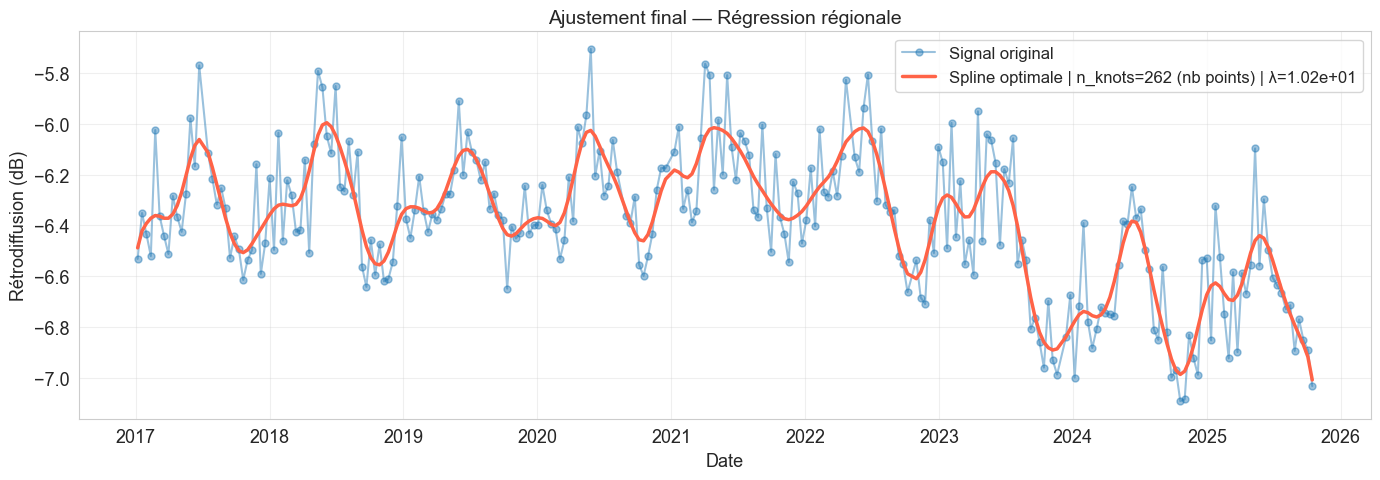

In [82]:
# VV masqué
ts_regional_vv_masked = extract_signal_regional("vv", "masked")

# VH non masqué
ts_regional_vh_masked = extract_signal_regional("vh", "masked")

# spline
result_regional_vh = run_regional_spline(ts_regional_vh_masked,use_mallows=False)   # sélection Cp automatique
result_regional_vv = run_regional_spline(ts_regional_vv_masked,use_mallows=False)   

# paramètres pour regression locale
lambda_regional_vh=result_regional_vh["lam"]
std_regional_vh= result_regional_vh["reg_std"]

lambda_regional_vv=result_regional_vv["lam"]
std_regional_vv= result_regional_vv["reg_std"]

## Zone 1

### Cas de VH

##### Test amélioration régionale

In [83]:
#ts_fol_z1_vh     = extract_signal_local(subzone=1, type_veg="fol", polarization="vh", orbite=120, direction="ASC")

#result_regional_z1_vh = run_local_spline(ts_fol_z1_vh,lambda_regional_vh,std_regional_vh,condition_cgv=True)      # n_knots = len(ts)

#std_regional_vh    = result_regional_z1_vh ["std_err"]
#lambda_regional_vh = result_regional_z1_vh ["lam"]

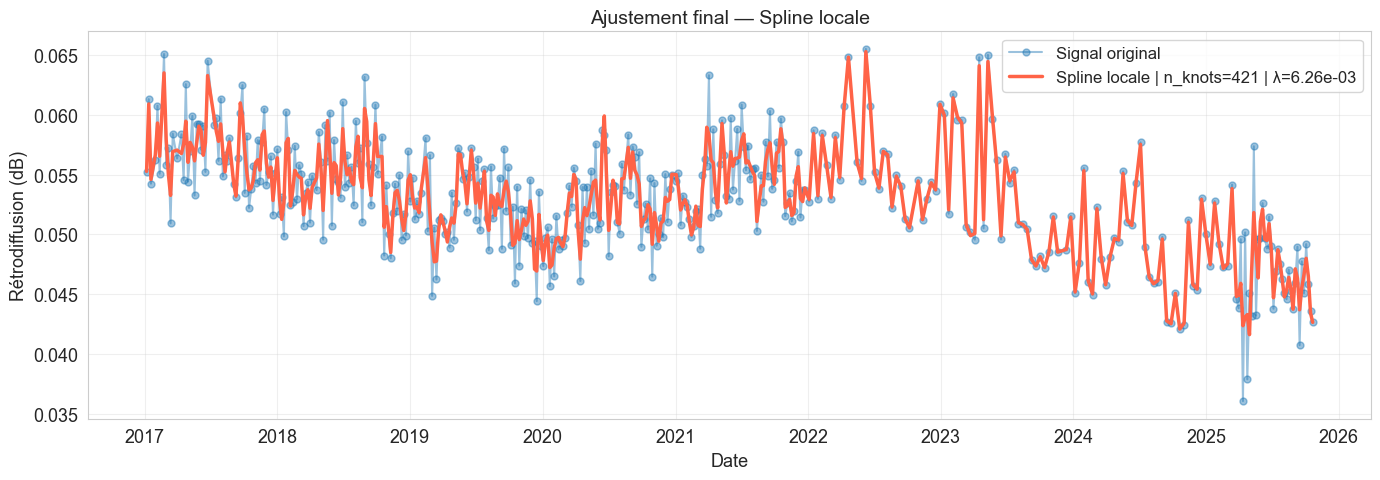

In [84]:
ts_defol_z1_vh     = extract_signal_local(subzone=1, type_veg="defol", polarization="vh", orbite=120, direction="ASC")

result_local_z1_vh = run_local_spline(ts_defol_z1_vh,lambda_regional_vh,std_regional_vh,condition_cgv=False)      # n_knots = len(ts)


### Cas de VV

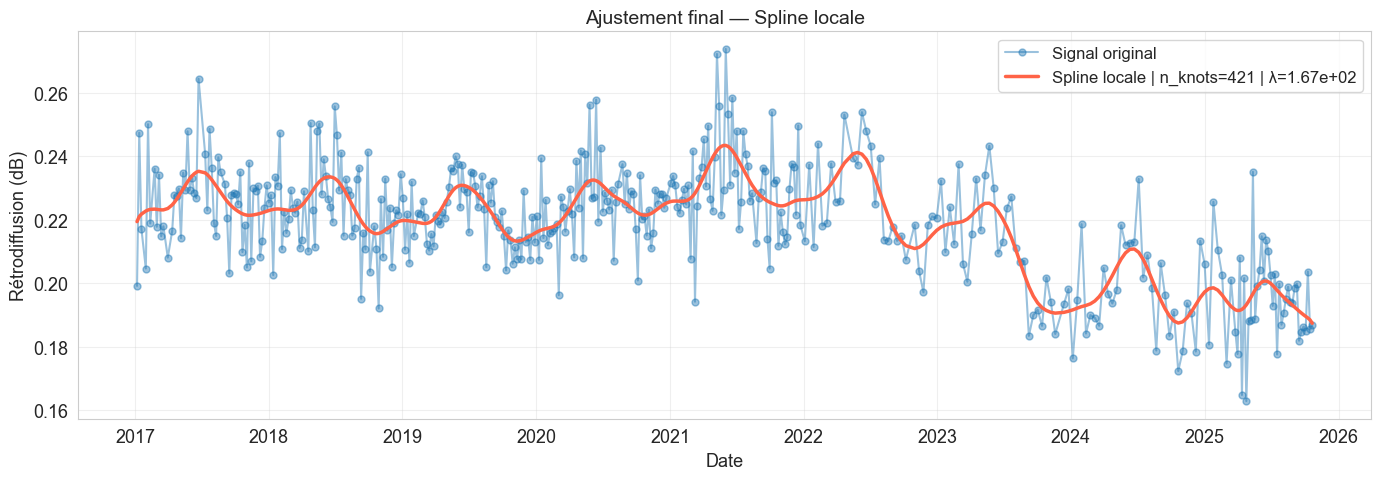

In [85]:
ts_defol_z1_vv        = extract_signal_local(subzone=1, type_veg="defol", polarization="vv", orbite=120, direction="ASC")

result_local_z1_vv    = run_local_spline(ts_defol_z1_vv,lambda_regional_vv,std_regional_vv,condition_cgv=True)      # n_knots = len(ts)

# Idée

In [86]:
FILEPATH_local = "data/Data/StudyCase_S1_Trinité/ts_10subzones_defoliated.csv"

def extract_signal_local_log(subzone, type_veg, polarization, orbite, direction, satellite=None):
    def to_list(val):
        return [val] if not isinstance(val, list) else val

    df = pd.read_csv(FILEPATH_local)
    df["subzone_id"] = df["shapefile_name"].str.extract(r"subzone(\d+)").astype(int)

    mask = (
        df["subzone_id"].isin(to_list(subzone)) &
        df["type"].isin(to_list(type_veg)) &
        df["polarization"].isin(to_list(polarization)) &
        df["orbite"].isin(to_list(orbite)) &
        df["direction"].isin(to_list(direction))
    )
    if satellite is not None:
        mask &= df["satellite"].isin(to_list(satellite))

    df_filtered = df[mask].copy()
    df_filtered["date"] = pd.to_datetime(df_filtered["date"], format="%Y%m%d")
    df_filtered["mean_value"] = 10 * np.log10(df_filtered["mean_value"])

    return df_filtered[["date", "mean_value"]].sort_values("date").reset_index(drop=True)

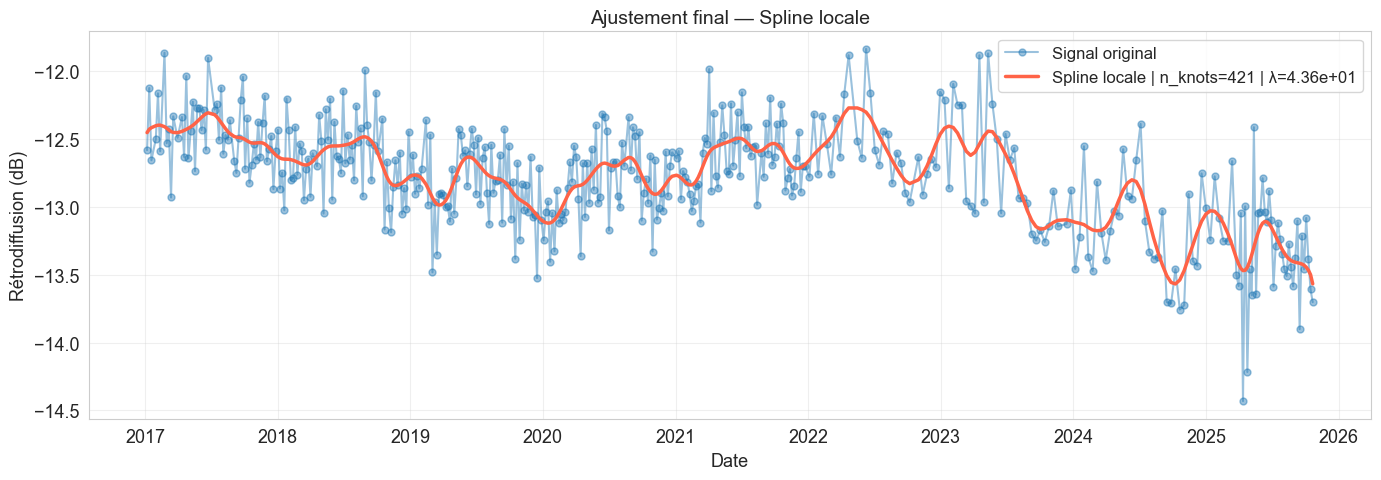

In [87]:
ts_defol_z1_vh     = extract_signal_local_log(subzone=1, type_veg="defol", polarization="vh", orbite=120, direction="ASC")

result_local_z1_vh = run_local_spline(ts_defol_z1_vh,lambda_regional_vh,std_regional_vh,condition_cgv=False)  